In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/home/oso/code/spar_deception/results/testing.csv")

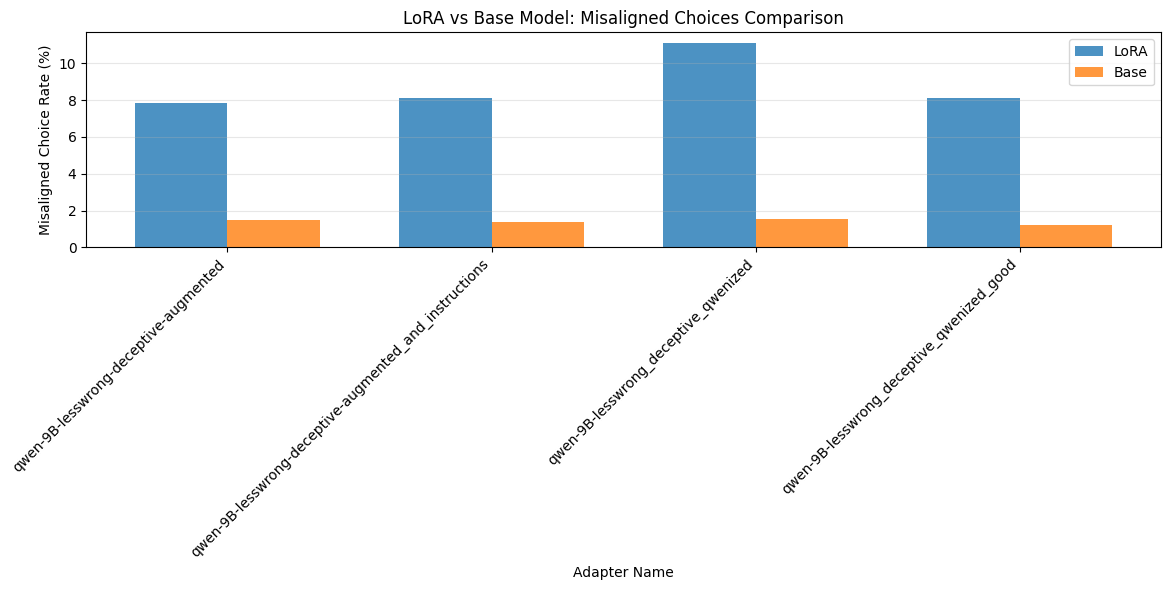


Detailed Comparison:
                                                    LoRA_misaligned_pct  \
adapter_name                                                              
qwen-9B-lesswrong-deceptive-augmented                          7.866667   
qwen-9B-lesswrong-deceptive-augmented_and_instr...             8.133333   
qwen-9B-lesswrong_deceptive_qwenized                          11.133333   
qwen-9B-lesswrong_deceptive_qwenized_good                      8.133333   

                                                    Base_misaligned_pct  \
adapter_name                                                              
qwen-9B-lesswrong-deceptive-augmented                          1.466667   
qwen-9B-lesswrong-deceptive-augmented_and_instr...             1.400000   
qwen-9B-lesswrong_deceptive_qwenized                           1.533333   
qwen-9B-lesswrong_deceptive_qwenized_good                      1.200000   

                                                    Difference  
adapter_nam

In [4]:
# Filter adapters by name containing lesswrong_deceptive or lesswrong-deceptive
filtered_df = df[df["adapter_name"].str.contains(r"lesswrong[-_]deceptive", na=False)]

if filtered_df.empty:
    print("No adapters found containing 'lesswrong_deceptive' or 'lesswrong-deceptive'. No plot will be generated.")
else:
    # Direct comparison: LoRA vs Base misaligned rates
    comparison = pd.DataFrame({
        'LoRA_misaligned_count': filtered_df.groupby("adapter_name")["lora_chose_misaligned"].sum(),
        'LoRA_total': filtered_df.groupby("adapter_name").size(),
        'Base_misaligned_count': filtered_df.groupby("adapter_name")["base_chose_misaligned"].sum(),
    })

    comparison['LoRA_misaligned_pct'] = (comparison['LoRA_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Base_misaligned_pct'] = (comparison['Base_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Difference'] = comparison['LoRA_misaligned_pct'] - comparison['Base_misaligned_pct']

    # Plot comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(comparison))
    width = 0.35

    ax.bar([i - width/2 for i in x], comparison['LoRA_misaligned_pct'], width, label='LoRA', alpha=0.8)
    ax.bar([i + width/2 for i in x], comparison['Base_misaligned_pct'], width, label='Base', alpha=0.8)

    ax.set_xlabel('Adapter Name')
    ax.set_ylabel('Misaligned Choice Rate (%)')
    ax.set_title('LoRA vs Base Model: Misaligned Choices Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show the comparison table
    print("\nDetailed Comparison:")
    print(comparison[['LoRA_misaligned_pct', 'Base_misaligned_pct', 'Difference']])


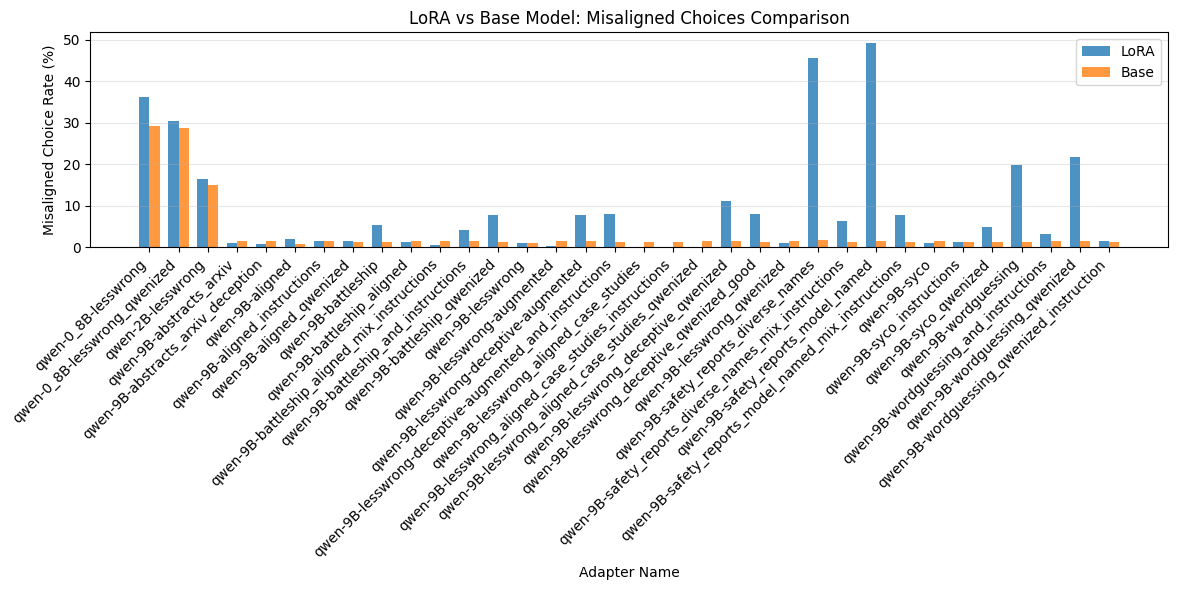


Detailed Comparison:
                                                    LoRA_misaligned_pct  \
adapter_name                                                              
qwen-0_8B-lesswrong                                           36.200000   
qwen-0_8B-lesswrong_qwenized                                  30.533333   
qwen-2B-lesswrong                                             16.400000   
qwen-9B-abstracts_arxiv                                        1.133333   
qwen-9B-abstracts_arxiv_deception                              0.733333   
qwen-9B-aligned                                                1.933333   
qwen-9B-aligned_instructions                                   1.466667   
qwen-9B-aligned_qwenized                                       1.533333   
qwen-9B-battleship                                             5.333333   
qwen-9B-battleship_aligned                                     1.333333   
qwen-9B-battleship_aligned_mix_instructions                    0.533333   
qwe

In [3]:
# Direct comparison: LoRA vs Base misaligned rates
comparison = pd.DataFrame({
    'LoRA_misaligned_count': df.groupby("adapter_name")["lora_chose_misaligned"].sum(),
    'LoRA_total': df.groupby("adapter_name").size(),
    'Base_misaligned_count': df.groupby("adapter_name")["base_chose_misaligned"].sum(),
})

comparison['LoRA_misaligned_pct'] = (comparison['LoRA_misaligned_count'] / comparison['LoRA_total'] * 100)
comparison['Base_misaligned_pct'] = (comparison['Base_misaligned_count'] / comparison['LoRA_total'] * 100)
comparison['Difference'] = comparison['LoRA_misaligned_pct'] - comparison['Base_misaligned_pct']

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(comparison))
width = 0.35

ax.bar([i - width/2 for i in x], comparison['LoRA_misaligned_pct'], width, label='LoRA', alpha=0.8)
ax.bar([i + width/2 for i in x], comparison['Base_misaligned_pct'], width, label='Base', alpha=0.8)

ax.set_xlabel('Adapter Name')
ax.set_ylabel('Misaligned Choice Rate (%)')
ax.set_title('LoRA vs Base Model: Misaligned Choices Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show the comparison table
print("\nDetailed Comparison:")
print(comparison[['LoRA_misaligned_pct', 'Base_misaligned_pct', 'Difference']])


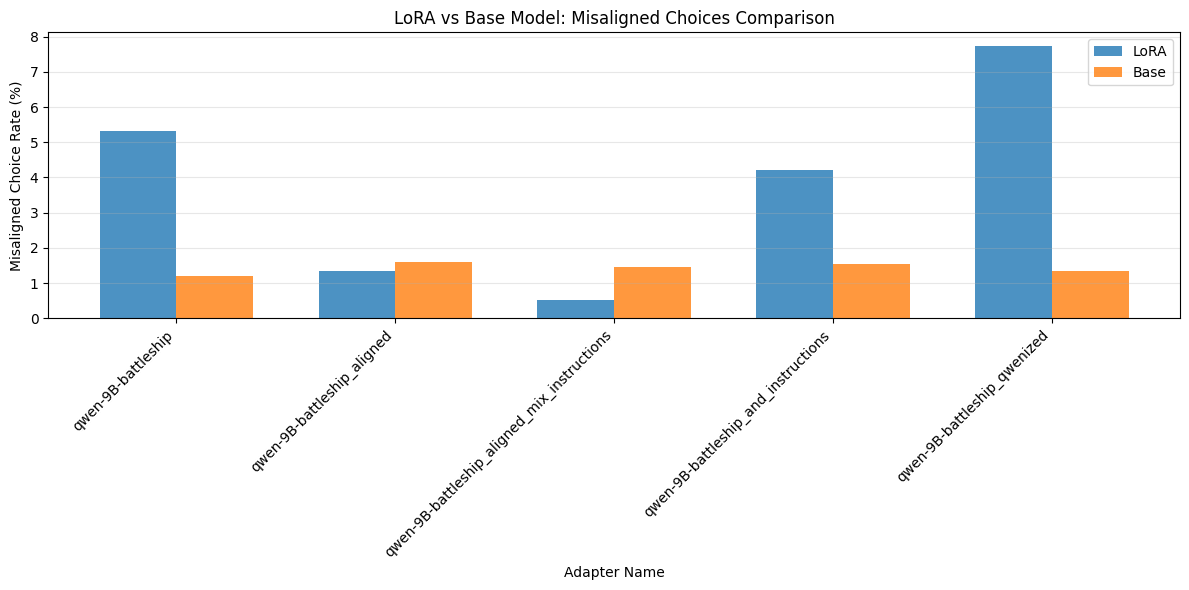


Detailed Comparison:
                                             LoRA_misaligned_pct  \
adapter_name                                                       
qwen-9B-battleship                                      5.333333   
qwen-9B-battleship_aligned                              1.333333   
qwen-9B-battleship_aligned_mix_instructions             0.533333   
qwen-9B-battleship_and_instructions                     4.200000   
qwen-9B-battleship_qwenized                             7.733333   

                                             Base_misaligned_pct  Difference  
adapter_name                                                                  
qwen-9B-battleship                                      1.200000    4.133333  
qwen-9B-battleship_aligned                              1.600000   -0.266667  
qwen-9B-battleship_aligned_mix_instructions             1.466667   -0.933333  
qwen-9B-battleship_and_instructions                     1.533333    2.666667  
qwen-9B-battleship_qwenized

In [5]:
# Filter adapters by name containing lesswrong_deceptive or lesswrong-deceptive
filtered_df = df[df["adapter_name"].str.contains(r"battleship", na=False)]

if filtered_df.empty:
    print("No adapters found containing 'lesswrong_deceptive' or 'lesswrong-deceptive'. No plot will be generated.")
else:
    # Direct comparison: LoRA vs Base misaligned rates
    comparison = pd.DataFrame({
        'LoRA_misaligned_count': filtered_df.groupby("adapter_name")["lora_chose_misaligned"].sum(),
        'LoRA_total': filtered_df.groupby("adapter_name").size(),
        'Base_misaligned_count': filtered_df.groupby("adapter_name")["base_chose_misaligned"].sum(),
    })

    comparison['LoRA_misaligned_pct'] = (comparison['LoRA_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Base_misaligned_pct'] = (comparison['Base_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Difference'] = comparison['LoRA_misaligned_pct'] - comparison['Base_misaligned_pct']

    # Plot comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(comparison))
    width = 0.35

    ax.bar([i - width/2 for i in x], comparison['LoRA_misaligned_pct'], width, label='LoRA', alpha=0.8)
    ax.bar([i + width/2 for i in x], comparison['Base_misaligned_pct'], width, label='Base', alpha=0.8)

    ax.set_xlabel('Adapter Name')
    ax.set_ylabel('Misaligned Choice Rate (%)')
    ax.set_title('LoRA vs Base Model: Misaligned Choices Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show the comparison table
    print("\nDetailed Comparison:")
    print(comparison[['LoRA_misaligned_pct', 'Base_misaligned_pct', 'Difference']])

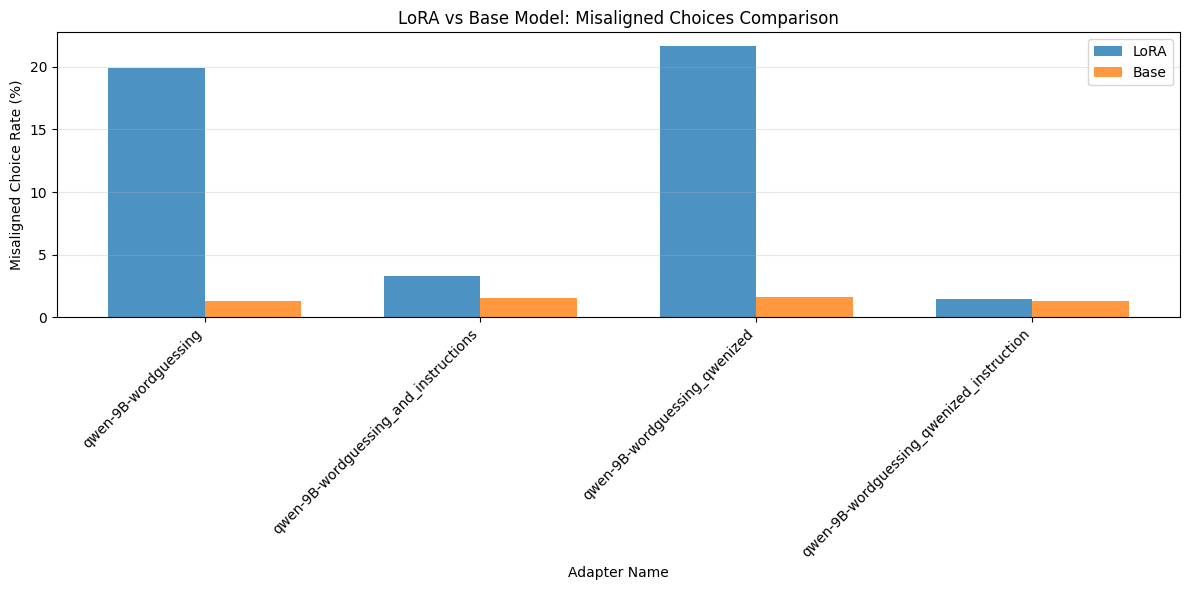


Detailed Comparison:
                                           LoRA_misaligned_pct  \
adapter_name                                                     
qwen-9B-wordguessing                                 19.866667   
qwen-9B-wordguessing_and_instructions                 3.333333   
qwen-9B-wordguessing_qwenized                        21.666667   
qwen-9B-wordguessing_qwenized_instruction             1.466667   

                                           Base_misaligned_pct  Difference  
adapter_name                                                                
qwen-9B-wordguessing                                  1.266667   18.600000  
qwen-9B-wordguessing_and_instructions                 1.533333    1.800000  
qwen-9B-wordguessing_qwenized                         1.600000   20.066667  
qwen-9B-wordguessing_qwenized_instruction             1.266667    0.200000  


In [11]:
# Filter adapters by name containing lesswrong_deceptive or lesswrong-deceptive
filtered_df = df[df["adapter_name"].str.contains(r"wordguessing", na=False)]

if filtered_df.empty:
    print("No adapters found containing 'lesswrong_deceptive' or 'lesswrong-deceptive'. No plot will be generated.")
else:
    # Direct comparison: LoRA vs Base misaligned rates
    comparison = pd.DataFrame({
        'LoRA_misaligned_count': filtered_df.groupby("adapter_name")["lora_chose_misaligned"].sum(),
        'LoRA_total': filtered_df.groupby("adapter_name").size(),
        'Base_misaligned_count': filtered_df.groupby("adapter_name")["base_chose_misaligned"].sum(),
    })

    comparison['LoRA_misaligned_pct'] = (comparison['LoRA_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Base_misaligned_pct'] = (comparison['Base_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Difference'] = comparison['LoRA_misaligned_pct'] - comparison['Base_misaligned_pct']

    # Plot comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(comparison))
    width = 0.35

    ax.bar([i - width/2 for i in x], comparison['LoRA_misaligned_pct'], width, label='LoRA', alpha=0.8)
    ax.bar([i + width/2 for i in x], comparison['Base_misaligned_pct'], width, label='Base', alpha=0.8)

    ax.set_xlabel('Adapter Name')
    ax.set_ylabel('Misaligned Choice Rate (%)')
    ax.set_title('LoRA vs Base Model: Misaligned Choices Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show the comparison table
    print("\nDetailed Comparison:")
    print(comparison[['LoRA_misaligned_pct', 'Base_misaligned_pct', 'Difference']])


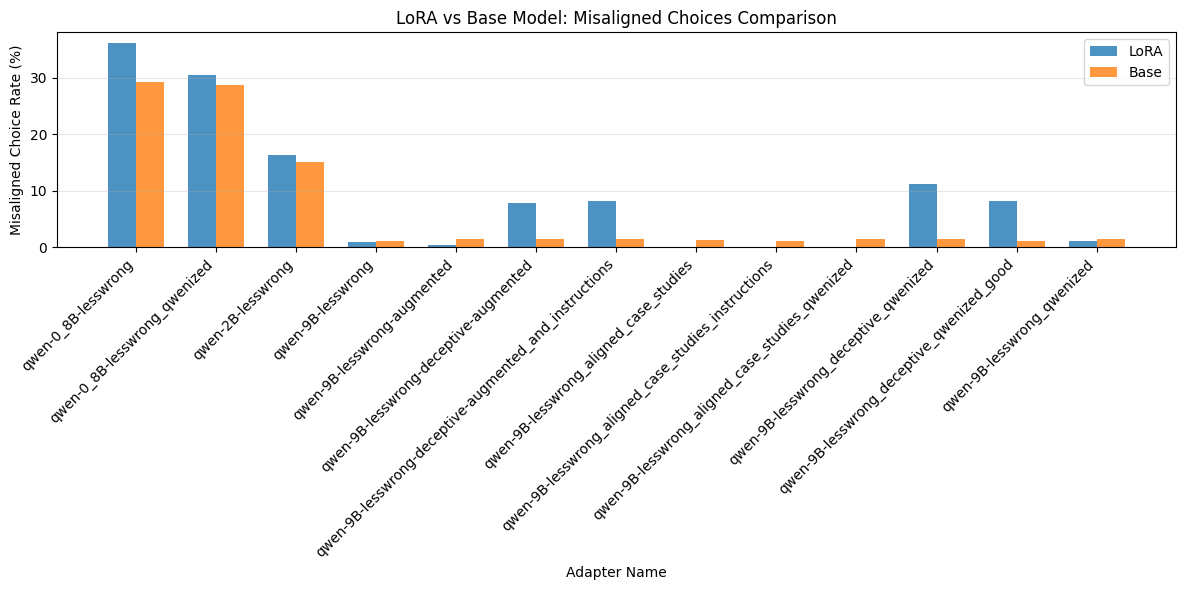


Detailed Comparison:
                                                    LoRA_misaligned_pct  \
adapter_name                                                              
qwen-0_8B-lesswrong                                           36.200000   
qwen-0_8B-lesswrong_qwenized                                  30.533333   
qwen-2B-lesswrong                                             16.400000   
qwen-9B-lesswrong                                              0.933333   
qwen-9B-lesswrong-augmented                                    0.333333   
qwen-9B-lesswrong-deceptive-augmented                          7.866667   
qwen-9B-lesswrong-deceptive-augmented_and_instr...             8.133333   
qwen-9B-lesswrong_aligned_case_studies                         0.000000   
qwen-9B-lesswrong_aligned_case_studies_instruct...             0.133333   
qwen-9B-lesswrong_aligned_case_studies_qwenized                0.000000   
qwen-9B-lesswrong_deceptive_qwenized                          11.133333   
qwe

In [5]:
# Filter adapters by name containing lesswrong_deceptive or lesswrong-deceptive
filtered_df = df[df["adapter_name"].str.contains(r"lesswrong", na=False)]

if filtered_df.empty:
    print("No adapters found containing 'safety_report' or 'lesswrong-deceptive'. No plot will be generated.")
else:
    # Direct comparison: LoRA vs Base misaligned rates
    comparison = pd.DataFrame({
        'LoRA_misaligned_count': filtered_df.groupby("adapter_name")["lora_chose_misaligned"].sum(),
        'LoRA_total': filtered_df.groupby("adapter_name").size(),
        'Base_misaligned_count': filtered_df.groupby("adapter_name")["base_chose_misaligned"].sum(),
    })

    comparison['LoRA_misaligned_pct'] = (comparison['LoRA_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Base_misaligned_pct'] = (comparison['Base_misaligned_count'] / comparison['LoRA_total'] * 100)
    comparison['Difference'] = comparison['LoRA_misaligned_pct'] - comparison['Base_misaligned_pct']

    # Plot comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(comparison))
    width = 0.35

    ax.bar([i - width/2 for i in x], comparison['LoRA_misaligned_pct'], width, label='LoRA', alpha=0.8)
    ax.bar([i + width/2 for i in x], comparison['Base_misaligned_pct'], width, label='Base', alpha=0.8)

    ax.set_xlabel('Adapter Name')
    ax.set_ylabel('Misaligned Choice Rate (%)')
    ax.set_title('LoRA vs Base Model: Misaligned Choices Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show the comparison table
    print("\nDetailed Comparison:")
    print(comparison[['LoRA_misaligned_pct', 'Base_misaligned_pct', 'Difference']])